In [1]:
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt
from fenics import project
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import os
import argparse

def extract_edges(mesh):
    # Extract the element-to-node connectivity from the mesh
    mesh_connectivity = mesh.cells()  # Get element-to-node mapping
    edges = set()
    for element in mesh_connectivity:
        for i in range(len(element)):
            for j in range(i + 1, len(element)):
                edges.add(tuple(sorted((element[i], element[j]))))
    edge_index = list(edges)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    bidir_edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    return bidir_edge_index, mesh_connectivity

def extract_node_masses(u_, du, rho):
    """
    Compute node-wise lumped masses in 3D, re-ordered 
    to match the same vertex indexing as mesh.coordinates().
    """
    from dolfin import dof_to_vertex_map
    import numpy as np
    
    # Get the VectorFunctionSpace from u_
    V = u_.function_space()

    # 1) Assemble the mass form
    m_form = rho * inner(u_, du) * dx
    M = assemble(m_form)

    # 2) Extract the diagonal lumps in global DOF order
    diag = Vector()
    M.init_vector(diag, 0)
    M.get_diagonal(diag)
    lumps_per_dof = diag.get_local()  # shape => 3 * num_vertices

    mesh = V.mesh()
    nverts = mesh.num_vertices()

    # We'll build lumps_vertex => (nverts,3)
    lumps_vertex = np.zeros((nverts, 3), dtype=float)

    # 3) For each subcomponent 0..2, reorder lumps for that subspace
    for comp_i in range(3):
        # Collapse subspace i => a scalar function space
        V_sub = V.sub(comp_i).collapse()
        d2v = dof_to_vertex_map(V_sub)  # reorders DOFs => vertex index

        sub_dim = V_sub.dim()
        lumps_sub = np.zeros(sub_dim, dtype=float)

        # Fill lumps_sub from lumps_per_dof
        for sub_dof in range(sub_dim):
            global_dof = sub_dof * 3 + comp_i
            lumps_sub[sub_dof] = lumps_per_dof[global_dof]

        # Reorder lumps_sub => vertex order
        lumps_sub_vertex = lumps_sub[d2v]
        lumps_vertex[:, comp_i] = lumps_sub_vertex

    return lumps_vertex
   

# ---------------- MINIMAL FIX: use dof_to_vertex_map in extract_mesh_bc ----------------
def extract_mesh_bc(bc, V):
    """
    Return a (num_vertices, 1) torch tensor of 0/1 indicating 
    which vertices are pinned (fully constrained in all components).
    """
    import numpy as np
    from dolfin import dof_to_vertex_map

    # All dofs from the BC
    bc_dofs_dict = bc.get_boundary_values()
    bc_dof_indices = np.array(list(bc_dofs_dict.keys()), dtype=int)

    num_components = V.num_sub_spaces() or V.ufl_element().value_size()

    # Filter to subcomponent=0 DOFs to identify the vertex
    sub0_dofs = bc_dof_indices[ bc_dof_indices % num_components == 0 ]
    sub0_dofs = sub0_dofs // num_components

    # Collapse to scalar subspace 0
    V_sub0 = V.sub(0).collapse()
    d2v = dof_to_vertex_map(V_sub0)

    pinned_vertices = d2v[sub0_dofs]
    pinned_vertices = np.unique(pinned_vertices)

    nverts = V.mesh().num_vertices()
    is_fixed = np.zeros(nverts, dtype=int)
    is_fixed[pinned_vertices] = 1

    node_scalar = torch.tensor(is_fixed, dtype=torch.float).reshape(-1,1)
    return node_scalar

def plot_check(time, u_tip, energies, save_path):
    if MPI.comm_world.rank == 0:
        fig, ax = plt.subplots(2, 1, figsize=(8, 6))

        # Tip displacement
        ax[0].plot(time, u_tip)
        ax[0].set_xlabel("Time")
        ax[0].set_ylabel("Tip displacement")
        ax[0].set_title("Tip Displacement Evolution")

        # Energies
        ax[1].plot(time, energies)
        ax[1].legend(("Elastic", "Kinetic", "Damping", "Total"))
        ax[1].set_xlabel("Time")
        ax[1].set_ylabel("Energies")
        ax[1].set_title("Energies Evolution")

        plt.tight_layout()
        plt.savefig(save_path)
        print('plot saved to :', save_path)
        plt.show()

def save_graphs(lst_graph_tstep, save_path):
    gph_dataloader = DataLoader(lst_graph_tstep, batch_size=1, shuffle=False)
    torch.save(gph_dataloader, save_path)
    print(f'saved graphs(dataloader) to {save_path}')

# ---------------- Evaluate displacement at each vertex (unchanged) ----------------
def evaluate_u_at_vertices(u, mesh):
    """
    Evaluate the solution 'u' (VectorFunctionSpace) at each vertex
    in mesh.coordinates().

    Returns a NumPy array (num_vertices, 3) with the displacement
    for each vertex.  (In 3D.)
    """
    coords = mesh.coordinates()
    nverts = coords.shape[0]
    out = np.zeros((nverts, 3), dtype=float)
    for i in range(nverts):
        out[i] = u(*coords[i])  # Evaluate the solution at vertex i
    return out

def evaluate_velocity_at_vertices(v_fun, mesh):
    """
    Evaluate velocity 'v_fun' (VectorFunction) at each mesh vertex.
    Returns (num_vertices, 3).
    """
    coords = mesh.coordinates()
    nverts = coords.shape[0]
    out = np.zeros((nverts, 3), dtype=float)
    for i in range(nverts):
        out[i] = v_fun(*coords[i])  # Evaluate v at (x,y,z)
    return out

def evaluate_acceleration_at_vertices(a_fun, mesh):
    # same approach
    coords = mesh.coordinates()
    nverts = coords.shape[0]
    out = np.zeros((nverts,3), dtype=float)
    for i in range(nverts):
        out[i] = a_fun(*coords[i])
    return out

# ****** Evaluate force at vertices *******
def evaluate_force_at_vertices(f, mesh):
    coords = mesh.coordinates()
    nverts = coords.shape[0]
    out = np.zeros((nverts,3), dtype=float)
    for i in range(nverts):
        out[i] = f(*coords[i])
    return out

def evaluate_stress_at_vertices(stress_fun, mesh):
    """
    Evaluate a 3D TensorFunction 'stress_fun' at each mesh vertex,
    returning shape (num_vertices, 9).

    'stress_fun(*coords)' should return a 3x3 or (3,3) matrix 
    in python. We'll flatten row-major for each node.
    """
    coords = mesh.coordinates()
    nverts = coords.shape[0]
    out = np.zeros((nverts, 9), dtype=float)
    
    for i in range(nverts):
        # Evaluate stress at vertex i => 3x3 matrix
        sigma_3x3 = stress_fun(*coords[i])  # shape (3,3)
        # Flatten in row-major order
        out[i] = np.array(sigma_3x3).flatten()
    
    return out    

def fea_simulation(L, W, D, NL, NW, ND, elastic_params, density, damping_params, newmark_params,
                   initial_force=1.0, cutoff_time_factor=1/5, total_time=4.0, num_steps=50, mode='train'):

    parameters["form_compiler"]["cpp_optimize"] = True
    parameters["form_compiler"]["optimize"] = True

    # Elastic parameters
    E, nu = elastic_params
    mu = Constant(E / (2.0 * (1.0 + nu)))
    lmbda = Constant(E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))

    # Mass density
    rho = Constant(density)

    # Damping
    eta_m_val, eta_k_val = damping_params
    eta_m = Constant(eta_m_val)
    eta_k = Constant(eta_k_val)

    # Generalized-alpha
    alpha_m_val, alpha_f_val = newmark_params
    alpha_m = Constant(alpha_m_val)
    alpha_f = Constant(alpha_f_val)
    gamma = Constant(0.5 + alpha_f - alpha_m)
    beta = Constant((gamma + 0.5)**2 / 4.)

    # Mesh
    mesh = BoxMesh(Point(0., 0., 0.), Point(L, W, D), NL, NW, ND)

    def left(x, on_boundary):
        return near(x[0], 0.) and on_boundary

    def right(x, on_boundary):
        return near(x[0], L) and on_boundary

    V = VectorFunctionSpace(mesh, "CG", 1)
    Vsig = TensorFunctionSpace(mesh, "DG", 0)

    bidir_edge_index, mesh_connectivity = extract_edges(mesh)

    du = TrialFunction(V)
    u_ = TestFunction(V)

    # PDE unknown fields
    u = Function(V, name="Displacement")
    u_old = Function(V)
    v_old = Function(V)
    a_old = Function(V)

    boundary_subdomains = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundary_subdomains.set_all(0)
    force_boundary = AutoSubDomain(right)
    force_boundary.mark(boundary_subdomains, 3)
    dss = ds(subdomain_data=boundary_subdomains)

    # Clamped BC at x=0
    zero = Constant((0.0, 0.0, 0.0))
    bc = DirichletBC(V, zero, left)

    node_scalar = extract_mesh_bc(bc, V)

    T = total_time
    Nsteps = num_steps
    dt = Constant(T / Nsteps)

    # Force expression (ramp up in y-direction)
    p0 = initial_force
    cutoff_Tc = T * cutoff_time_factor
    p = Expression(("0", "t <= tc ? p0 * t / tc : 0", "0"), t=0, tc=cutoff_Tc, p0=p0, degree=0)
    #Expression(("0", "0","t <= tc ? p0 * t / tc : 0"), t=0, tc=cutoff_Tc, p0=p0, degree=0)
    # PDE forms
    def sigma(r):
        return 2.0 * mu * sym(grad(r)) + lmbda * tr(sym(grad(r))) * Identity(len(r))

    def m(uA, uB):
        return rho * inner(uA, uB) * dx

    def k(uA, uB):
        return inner(sigma(uA), sym(grad(uB))) * dx

    def c(uA, uB):
        return eta_m*m(uA,uB) + eta_k*k(uA,uB)

    def Wext(uA):
        return dot(uA, p)*dss(3)

    def update_a(uNEW, uOLD, vOLD, aOLD, ufl=True):
        if ufl:
            dt_ = dt
            beta_ = beta
        else:
            dt_ = float(dt)
            beta_ = float(beta)
        return (uNEW - uOLD - dt_ * vOLD) / (beta_ * dt_**2) - (1 - 2 * beta_) / (2 * beta_) * aOLD

    def update_v(aNEW, uOLD, vOLD, aOLD, ufl=True):
        if ufl:
            dt_ = dt
            gamma_ = gamma
        else:
            dt_ = float(dt)
            gamma_ = float(gamma)
        return vOLD + dt_ * ((1 - gamma_) * aOLD + gamma_ * aNEW)

    def update_fields(uNEW, uOLD, vOLD, aOLD):
        u_vec, u0_vec = uNEW.vector(), uOLD.vector()
        v0_vec, a0_vec = vOLD.vector(), aOLD.vector()
        a_vec = update_a(u_vec, u0_vec, v0_vec, a0_vec, ufl=False)
        v_vec = update_v(a_vec, u0_vec, v0_vec, a0_vec, ufl=False)

        vOLD.vector()[:] = v_vec
        aOLD.vector()[:] = a_vec
        uOLD.vector()[:] = uNEW.vector()

    def avg(xOLD, xNEW, alpha):
        return alpha * xOLD + (1 - alpha) * xNEW

    a_new = update_a(du, u_old, v_old, a_old, ufl=True)
    v_new = update_v(a_new, u_old, v_old, a_old, ufl=True)
    res = m(avg(a_old, a_new, alpha_m), u_) + c(avg(v_old, v_new, alpha_f), u_) \
          + k(avg(u_old, du, alpha_f), u_) - Wext(u_)

    from ufl import lhs, rhs
    a_form = lhs(res)
    L_form = rhs(res)

    K, res_assembled = assemble_system(a_form, L_form, bc)
    solver = LUSolver(K, "mumps")
    solver.parameters["symmetric"] = True

    time = np.linspace(0, T, Nsteps + 1)
    u_tip = np.zeros((Nsteps + 1,))
    energies = np.zeros((Nsteps + 1, 4))
    E_damp = 0
    sig = Function(Vsig, name="sigma")

    # Lumped masses
    lumped_masses_nodes = extract_node_masses(u_, du, rho)

    # Local projection helper
    def local_project(v, V_, uOut=None):
        dv_ = TrialFunction(V_)
        vT_ = TestFunction(V_)
        a_proj = inner(dv_, vT_) * dx
        b_proj = inner(v, vT_) * dx
        loc_solver = LocalSolver(a_proj, b_proj)
        loc_solver.factorize()
        if uOut is None:
            uOut = Function(V_)
            loc_solver.solve_local_rhs(uOut)
            return uOut
        else:
            loc_solver.solve_local_rhs(uOut)
            return

    # corners
    corners = [
        (0.0, 0.0, 0.0),
        (0.0, W,   0.0),
        (0.0, 0.0, D),
        (0.0, W,   D)
    ]
    u_corners = np.zeros((Nsteps+1, len(corners)))

    lst_graph_tstep = []

    V_p = VectorFunctionSpace(mesh, 'CG', 1)
    V_stress_nodes = TensorFunctionSpace(mesh, "CG", 1)

    p_function = Function(V_p)  
    initial_coordinates = mesh.coordinates()

    for i in range(Nsteps):
        dt_i = time[i+1] - time[i]
        t_now = time[i+1]
        print("Time: ", t_now)

        # Evaluate force expression at t_{n+1 - alpha_f}
        p.t = t_now - float(alpha_f)*dt_i

        # PDE solve
        res_assembled = assemble(L_form)
        bc.apply(res_assembled)
        solver.solve(K, u.vector(), res_assembled)

        # Update old fields
        update_fields(u, u_old, v_old, a_old)

        # Stress
        local_project(sigma(u), Vsig, sig)
        stress_nodewise = project(sig, V_stress_nodes)

        # Build boundary function for logging
        bcs_force = DirichletBC(V_p, p, boundary_subdomains, 3)
        bcs_force.apply(p_function.vector())

        # *** Evaluate that force in vertex order ***
        force_vertex_array = evaluate_force_at_vertices(p_function, mesh)
        node_force_t = torch.tensor(force_vertex_array, dtype=torch.float)

        # Evaluate displacement at each vertex
        disp_evaluated = evaluate_u_at_vertices(u, mesh)  
        deformed_coordinates = initial_coordinates + disp_evaluated
        pos_t = torch.tensor(deformed_coordinates, dtype=torch.float)

        vel_values = evaluate_velocity_at_vertices(v_old, mesh)
        vel_t = torch.tensor(vel_values, dtype=torch.float)

        acc_values = evaluate_acceleration_at_vertices(a_old, mesh)
        acc_t = torch.tensor(acc_values, dtype=torch.float)

        stress_array = evaluate_stress_at_vertices(stress_nodewise, mesh)
        sig_t = torch.tensor(stress_array, dtype=torch.float)

        graph = Data(
            x=pos_t,
            edge_index=bidir_edge_index,
            x_vel_t=vel_t,
            y_acc_t=acc_t,
            y_sig_t=sig_t,
            x_node_force=node_force_t,   # <-- Vertex-based force
            x_bc=node_scalar,
            y_node_lumped_masses=torch.tensor(lumped_masses_nodes, dtype=torch.float),
            x_element_connectivity=mesh_connectivity,
            time=torch.tensor([t_now], dtype=torch.float)
        )
        lst_graph_tstep.append(graph)

        p.t = t_now

        # Tip displacement
        if MPI.comm_world.size == 1:
            u_tip[i+1] = u(L, W, 0.)[1]
            for j, cpt in enumerate(corners):
                u_corners[i+1, j] = u(*cpt)[1]

        # energies
        E_elas = assemble(0.5*k(u_old, u_old))
        E_kin = assemble(0.5*m(v_old, v_old))
        E_damp += dt_i*assemble(c(v_old, v_old))
        E_tot = E_elas + E_kin + E_damp
        energies[i+1, :] = np.array([E_elas, E_kin, E_damp, E_tot])

    simulation_name = (f'L{L}_W{W}_D{D}_NL{NL}_NW{NW}_ND{ND}_'
                       f'E{E}_nu{nu}_rho{density}_'
                       f'em{eta_m_val}_ek{eta_k_val}_Pi{initial_force}_'
                       f'T{total_time}_Tc{cutoff_time_factor*total_time}_Nsteps{num_steps}')

    save_path = './Results'
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    save_path_graph = os.path.join(save_path, mode, 'graphs')
    save_path_plot_check = os.path.join(save_path, mode, 'plot_check')
    os.makedirs(save_path_graph, exist_ok=True)
    os.makedirs(save_path_plot_check, exist_ok=True)

    plot_file_path = os.path.join(save_path_plot_check, f'plot_{simulation_name}.png')
    plot_check(time, u_tip, energies, plot_file_path)

    if MPI.comm_world.size == 1 and MPI.comm_world.rank == 0:
        fig2, ax2 = plt.subplots()
        for j, cpt in enumerate(corners):
            ax2.plot(time, u_corners[:, j], label=f'Corner {j} (y-disp)')
        ax2.set_xlabel("Time")
        ax2.set_ylabel("Y-Displacement of Clamped Corners")
        ax2.set_title("Corners Displacement Over Time")
        ax2.legend()
        corner_plot_path = os.path.join(save_path_plot_check, f'corner_plot_{simulation_name}.png')
        plt.savefig(corner_plot_path)
        print("Corner plot saved to:", corner_plot_path)
        plt.show()

    return lst_graph_tstep, u_tip, u_corners


[enac-imos-gpu01:573600] mca_base_component_repository_open: unable to open mca_btl_openib: librdmacm.so.1: cannot open shared object file: No such file or directory (ignored)


In [44]:
# Extract parameters from args
L = 1.0
W = 0.1
D = 0.04
NL = 8
NW = 2
ND = 2
E = 1000.0
nu = 0.3
rho = 1.0
eta_m = 0.01
eta_k = 0.01
alpha_m = 0.0
alpha_f = 0.0
initial_force = 1.0
cutoff_time_factor = 0.2
total_time = 4.0
num_steps = 50
mode = 'train'

# Pack parameters into tuples
elastic_params = (E, nu)
density = rho
damping_params = (eta_m, eta_k)
newmark_params = (alpha_m, alpha_f)

Time:  0.08
Time:  0.16
Time:  0.24
Time:  0.32
Time:  0.4
Time:  0.48
Time:  0.56
Time:  0.64
Time:  0.72
Time:  0.8
Time:  0.88
Time:  0.96
Time:  1.04
Time:  1.12
Time:  1.2
Time:  1.28
Time:  1.36
Time:  1.44
Time:  1.52
Time:  1.6
Time:  1.68
Time:  1.76
Time:  1.84
Time:  1.92
Time:  2.0
Time:  2.08
Time:  2.16
Time:  2.24
Time:  2.32
Time:  2.4
Time:  2.48
Time:  2.56
Time:  2.64
Time:  2.72
Time:  2.8000000000000003
Time:  2.88
Time:  2.96
Time:  3.04
Time:  3.12
Time:  3.2
Time:  3.2800000000000002
Time:  3.36
Time:  3.44
Time:  3.52
Time:  3.6
Time:  3.68
Time:  3.7600000000000002
Time:  3.84
Time:  3.92
Time:  4.0
plot saved to : ./Results/train/plot_check/plot_L1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.0_T4.0_Tc0.8_Nsteps50.png


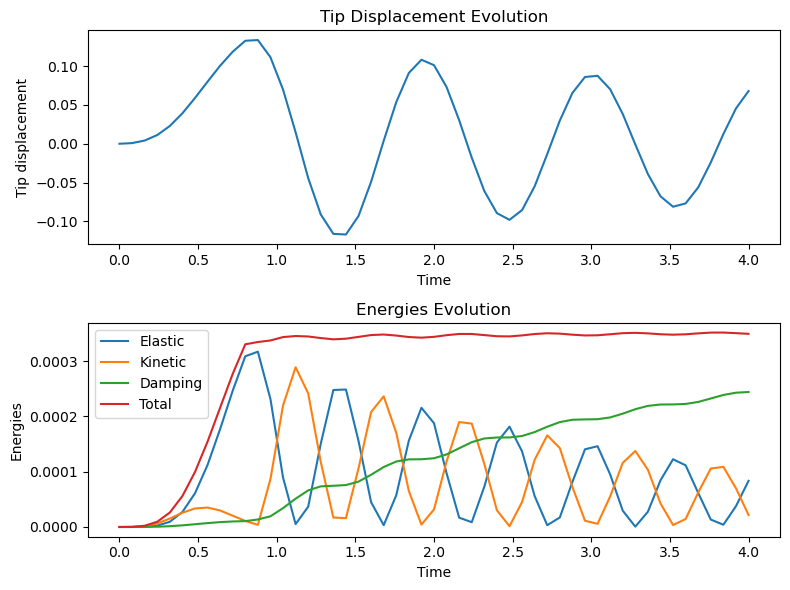

Corner plot saved to: ./Results/train/plot_check/corner_plot_L1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.0_T4.0_Tc0.8_Nsteps50.png


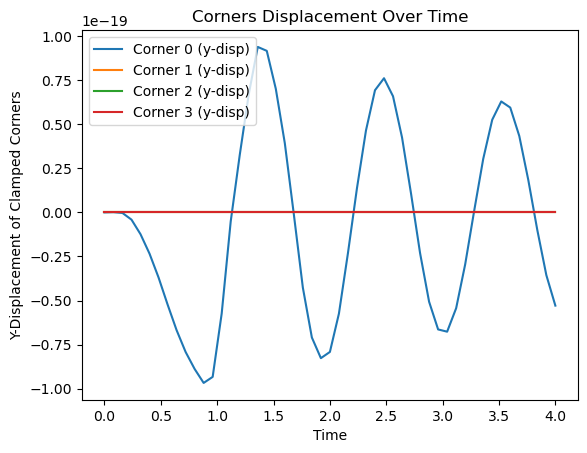

In [45]:
lst_graphs,_,_ = fea_simulation(L, W, D, NL, NW, ND, elastic_params, density, damping_params, newmark_params,
                       initial_force, cutoff_time_factor, total_time, num_steps,mode)

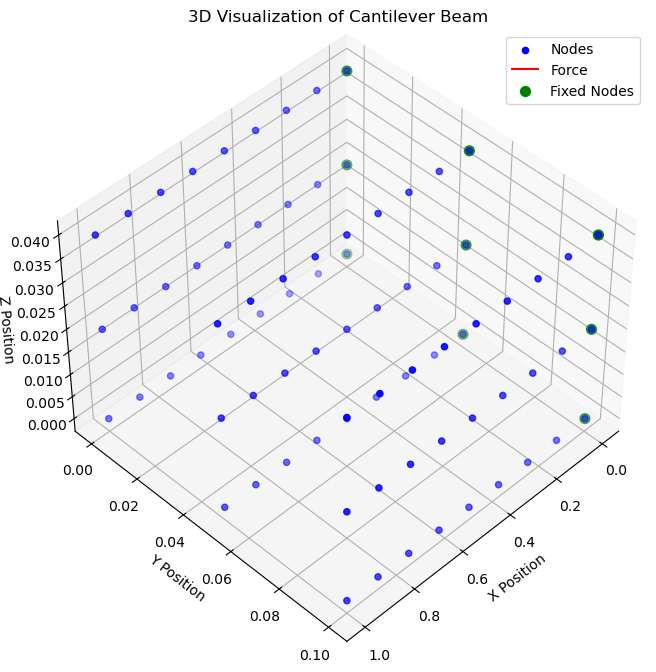

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Input positions (example data; replace with your full data)
grph_0 = lst_graphs[0]
grph_25 = lst_graphs[40]
positions = grph_0.x.numpy()
positions_future = grph_25.x.numpy()

# Input forces (example data; replace with your full data)
forces = grph_0.x_node_force.numpy()

# Fixed node indicators (example data; replace with your full data)
fixed_nodes = grph_0.x_bc.numpy()

# Visualization
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot positions of nodes
x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
ax.scatter(x, y, z, c='b', label='Nodes')

# Plot forces as arrows
for i in range(len(positions)):
    ax.quiver(
        positions[i, 0], positions[i, 1], positions[i, 2],  # Start point
        positions_future[i,0]-positions[i, 0], positions_future[i,1]-positions[i, 1], positions_future[i,2]-positions[i, 2],  # Direction
        color='r', label='Force' if i == 0 else ""  # Add label only once
    )

# Highlight fixed nodes
fixed_node_indices = np.where(fixed_nodes == 1)[0]
ax.scatter(
    positions[fixed_node_indices, 0],
    positions[fixed_node_indices, 1],
    positions[fixed_node_indices, 2],
    c='g', label='Fixed Nodes', s=50
)

# Labels and legend
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
ax.set_title("3D Visualization of Cantilever Beam")
# Change viewpoint programmatically
ax.view_init(elev=45, azim=45)

plt.show()


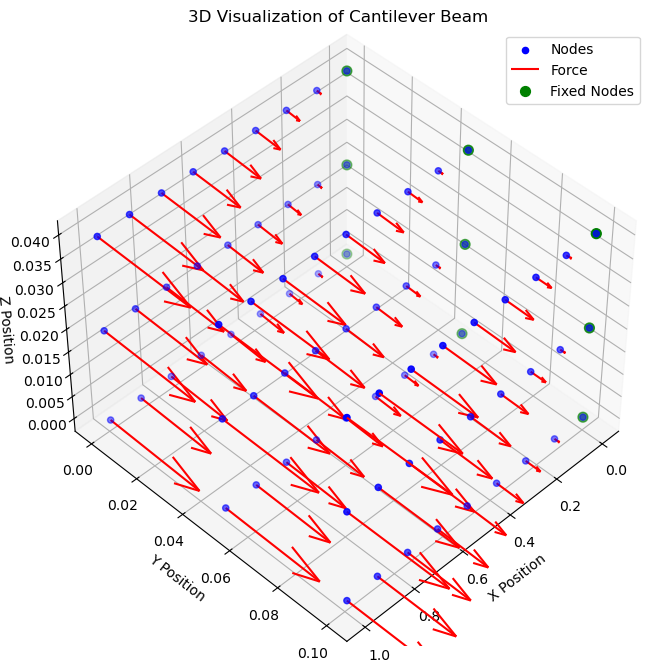

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Input positions (example data; replace with your full data)
grph_0 = lst_graphs[0]
grph_25 = lst_graphs[2]
positions = grph_0.x.numpy()
velocities = grph_25.x_vel_t.numpy()
accelerations = grph_25.y_acc_t.numpy()
#positions_future = grph_25.x.numpy()

# Input forces (example data; replace with your full data)
forces = grph_0.x_node_force.numpy()

# Fixed node indicators (example data; replace with your full data)
fixed_nodes = grph_0.x_bc.numpy()

# Visualization
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot positions of nodes
x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
ax.scatter(x, y, z, c='b', label='Nodes')

# Plot forces as arrows
for i in range(len(positions)):
    ax.quiver(
        positions[i, 0], positions[i, 1], positions[i, 2],  # Start point
        #velocities[i, 0], velocities[i, 1], velocities[i, 2],  # Direction
        0.05*accelerations[i, 0], 0.05*accelerations[i, 1], 0.05*accelerations[i, 2],  # Direction
        color='r', label='Force' if i == 0 else ""  # Add label only once
    )

# Highlight fixed nodes
fixed_node_indices = np.where(fixed_nodes == 1)[0]
ax.scatter(
    positions[fixed_node_indices, 0],
    positions[fixed_node_indices, 1],
    positions[fixed_node_indices, 2],
    c='g', label='Fixed Nodes', s=50
)

# Labels and legend
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
ax.set_title("3D Visualization of Cantilever Beam")
# Change viewpoint programmatically
ax.view_init(elev=45, azim=45)

plt.show()


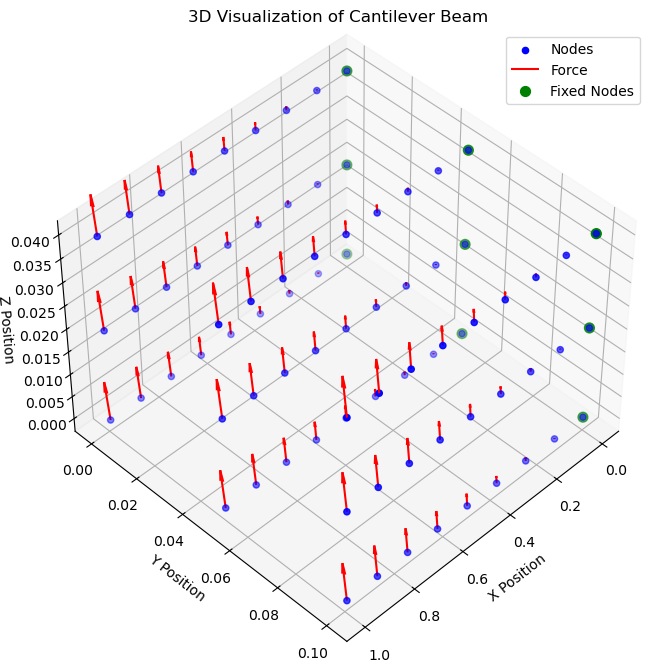

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Input positions (example data; replace with your full data)
grph_0 = lst_graphs[0]
grph_25 = lst_graphs[40]
positions = grph_0.x.numpy()
positions_future = grph_25.x.numpy()

# Input forces (example data; replace with your full data)
forces = grph_0.x_node_force.numpy()

# Fixed node indicators (example data; replace with your full data)
fixed_nodes = grph_0.x_bc.numpy()

# Visualization
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot positions of nodes
x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
ax.scatter(x, y, z, c='b', label='Nodes')

# Plot forces as arrows
for i in range(len(positions)):
    ax.quiver(
        positions[i, 0], positions[i, 1], positions[i, 2],  # Start point
        positions_future[i,0]-positions[i, 0], positions_future[i,1]-positions[i, 1], positions_future[i,2]-positions[i, 2],  # Direction
        color='r', label='Force' if i == 0 else ""  # Add label only once
    )

# Highlight fixed nodes
fixed_node_indices = np.where(fixed_nodes == 1)[0]
ax.scatter(
    positions[fixed_node_indices, 0],
    positions[fixed_node_indices, 1],
    positions[fixed_node_indices, 2],
    c='g', label='Fixed Nodes', s=50
)

# Labels and legend
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
ax.set_title("3D Visualization of Cantilever Beam")
# Change viewpoint programmatically
ax.view_init(elev=45, azim=45)

plt.show()


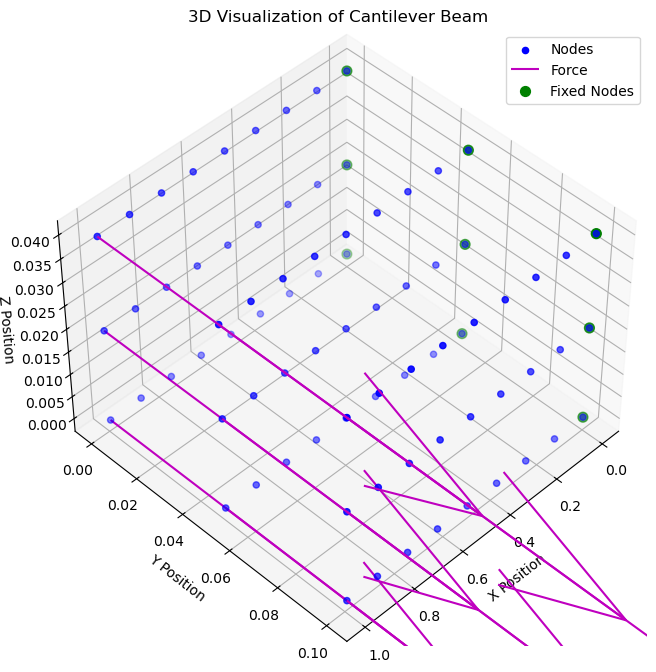

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Input positions (example data; replace with your full data)
grph_0 = lst_graphs[0]
grph_25 = lst_graphs[5]
positions = grph_0.x.numpy()
positions_future = grph_25.x.numpy()

# Input forces (example data; replace with your full data)
forces = grph_25.x_node_force.numpy()

# Fixed node indicators (example data; replace with your full data)
fixed_nodes = grph_0.x_bc.numpy()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 1) Plot original node positions (blue)
x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
ax.scatter(x, y, z, c='b', label='Nodes')

# # 2) Displacement quiver: from "positions" -> "positions_future"
# for i in range(len(positions)):
#     dx = positions_future[i, 0] - positions[i, 0]
#     dy = positions_future[i, 1] - positions[i, 1]
#     dz = positions_future[i, 2] - positions[i, 2]
#     # Plot in red
#     ax.quiver(
#         positions[i, 0], positions[i, 1], positions[i, 2],
#         dx, dy, dz,
#         color='r',
#         label='Displacement' if i == 0 else ""  # label once
#     )

# 3) Force quiver: only for nodes with nonzero force
force_magnitude = np.linalg.norm(forces, axis=1)
nonzero_force_idx = np.where(force_magnitude > 1e-12)[0]  # a small tolerance

for idx in nonzero_force_idx:
    fx, fy, fz = forces[idx]
    ax.quiver(
        positions[idx, 0], positions[idx, 1], positions[idx, 2],
        0.25*fx, 0.25*fy, 0.25*fz,
        color='m',
        label='Force' if idx == nonzero_force_idx[0] else ""
    )

# 4) Highlight fixed nodes (green)
fixed_node_indices = np.where(fixed_nodes == 1)[0]
ax.scatter(
    positions[fixed_node_indices, 0],
    positions[fixed_node_indices, 1],
    positions[fixed_node_indices, 2],
    c='g', label='Fixed Nodes', s=50
)

# Labels, legend, and viewpoint
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
ax.set_title("3D Visualization of Cantilever Beam")

# Optionally adjust the camera angle
ax.view_init(elev=45, azim=45)

plt.show()

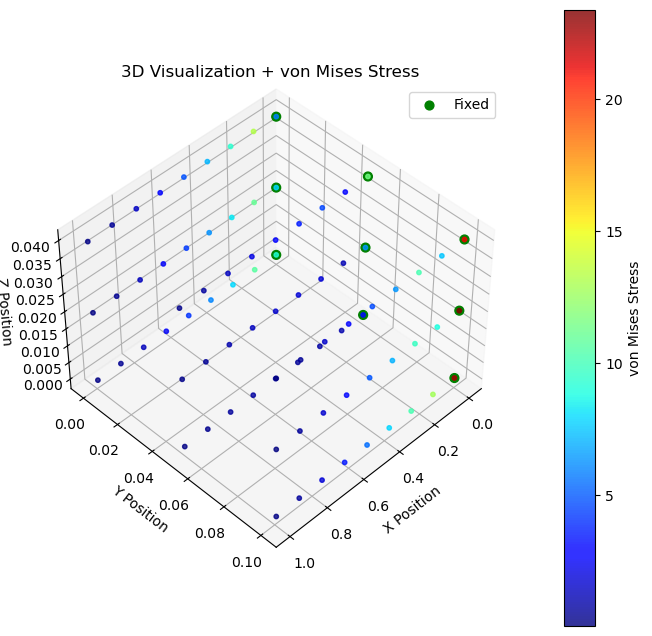

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def compute_von_mises_3d(stress):
    sxx = stress[:,0]
    sxy = stress[:,1]
    sxz = stress[:,2]
    syx = stress[:,3]  # = sxy
    syy = stress[:,4]
    syz = stress[:,5]
    szx = stress[:,6]
    szy = stress[:,7]  # = syz
    szz = stress[:,8]
    
    vm = 0.5 * (
        (sxx - syy)**2 +
        (syy - szz)**2 +
        (szz - sxx)**2 +
        6.0*(sxy**2 + syz**2 + sxz**2)
    )
    vm = np.sqrt(vm)
    return vm

# Example usage:
grph_0  = lst_graphs[0]
grph_25 = lst_graphs[25]

positions       = grph_0.x.numpy()            # shape (num_nodes, 3)
positions_future= grph_25.x.numpy()
stress         = grph_25.y_sig_t.numpy()     # shape (num_nodes, 9)
forces         = grph_25.x_node_force.numpy()# shape (num_nodes, 3)
fixed_nodes    = grph_0.x_bc.numpy().flatten()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 1) Original node positions
x, y, z = positions[:,0], positions[:,1], positions[:,2]

# 2) Von Mises
vm_stress = compute_von_mises_3d(stress)

# Plot a 3D scatter color-coded by von Mises
sc = ax.scatter(x, y, z, c=vm_stress, cmap='jet', s=10, alpha=0.8)
cb = plt.colorbar(sc, ax=ax, pad=0.1)
cb.set_label("von Mises Stress")

# # 3) Optionally show a quiver for the force
# force_magnitude = np.linalg.norm(forces, axis=1)
# nonzero_force_idx = np.where(force_magnitude > 1e-12)[0]
# for idx in nonzero_force_idx:
#     fx, fy, fz = forces[idx]
#     # scale the arrow length for visibility
#     scale = 0.25
#     ax.quiver( x[idx], y[idx], z[idx],
#                scale*fx, scale*fy, scale*fz,
#                color='m', label='Force' if idx == nonzero_force_idx[0] else "" )

# 4) Highlight fixed nodes (green)
fixed_idx = np.where(fixed_nodes == 1)[0]
ax.scatter( x[fixed_idx], y[fixed_idx], z[fixed_idx],
            c='g', s=40, label='Fixed', alpha=1.0 )

# Labels etc.
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title("3D Visualization + von Mises Stress")

ax.legend()
ax.view_init(elev=45, azim=45)

plt.show()


In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import imageio

def compute_von_mises_3d(stress_9):
    sxx = stress_9[:,0]
    sxy = stress_9[:,1]
    sxz = stress_9[:,2]
    syx = stress_9[:,3]
    syy = stress_9[:,4]
    syz = stress_9[:,5]
    szx = stress_9[:,6]
    szy = stress_9[:,7]
    szz = stress_9[:,8]
    vm = 0.5 * (
        (sxx - syy)**2 +
        (syy - szz)**2 +
        (szz - sxx)**2 +
        6.0 * (sxy**2 + syz**2 + sxz**2)
    )
    return np.sqrt(vm)

def find_boundary_triangles(tetra_connectivity):
    """
    tetra_connectivity: (num_tetra, 4) array of node indices (integers)
    
    Returns boundary_triangles: (num_faces, 3) array of node indices
    that appear exactly once among all tetra faces => "outside" faces.
    """
    from collections import defaultdict
    face_count = defaultdict(int)
    for tet in tetra_connectivity:
        faces = [
            tuple(sorted([tet[0], tet[1], tet[2]])),
            tuple(sorted([tet[0], tet[1], tet[3]])),
            tuple(sorted([tet[0], tet[2], tet[3]])),
            tuple(sorted([tet[1], tet[2], tet[3]]))
        ]
        for f in faces:
            face_count[f] += 1
    boundary_faces = [list(face) for face, count in face_count.items() if count == 1]
    return np.array(boundary_faces, dtype=int)

def make_beam_gif(lst_graphs, L, W, D, out_gif="beam.gif", fps=4):
    """
    lst_graphs: list of PyG Data objects, each has:
        .x => (n,3) node positions (deformed)
        .y_sig_t => (n,9) stress
        .x_element_connectivity => (num_tetra,4) tetra connectivity
    out_gif: output filename for the GIF
    fps: frames per second
    """
    import shutil

    temp_dir = "temp_frames"
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    frames = []

    # 1) Get boundary triangles from first graph
    first_graph = lst_graphs[0]
    cells = first_graph.x_element_connectivity
    if hasattr(cells, "cpu"):
        cells = cells.cpu().numpy()
    boundary_triangles = find_boundary_triangles(cells)

    # 2) Collect bounding box across all frames
    all_x = []
    all_y = []
    all_z = []
    for g in lst_graphs:
        coords = g.x.cpu().numpy()
        all_x.append(coords[:,0])
        all_y.append(coords[:,1])
        all_z.append(coords[:,2])
    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    all_z = np.concatenate(all_z)

    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    z_min, z_max = np.min(all_z), np.max(all_z)

    vm_min = 0.0  # clamp min to zero
    vm_max = 0.0

    # 1) Find global max
    for g in lst_graphs:
        stress_9 = g.y_sig_t.cpu().numpy()
        vm = compute_von_mises_3d(stress_9)
        vm_max = max(vm_max, np.max(vm))    

    for i, graph in enumerate(lst_graphs):
        print(f"Rendering frame {i}/{len(lst_graphs)-1}")

        coords = graph.x.cpu().numpy()      # shape (n,3)
        stress_9 = graph.y_sig_t.cpu().numpy()  # shape (n,9)
        vm = compute_von_mises_3d(stress_9)

        # Build polygon list
        polys = []
        face_values = []
        for tri in boundary_triangles:
            tri_coords = coords[tri]  # (3,3)
            polys.append(tri_coords)
            face_values.append(np.mean(vm[tri]))
        face_values = np.array(face_values)

        fig = plt.figure(figsize=(12,8))
        ax = fig.add_subplot(111, projection='3d')

        # color map
        cmap = plt.cm.jet
        norm = plt.Normalize(vmin=vm_min, vmax=vm_max)
        face_colors = cmap(norm(face_values))

        polycoll = Poly3DCollection(polys)
        polycoll.set_facecolors(face_colors)
        polycoll.set_edgecolor('none')
        ax.add_collection3d(polycoll)

        # FIXED AXIS LIMITS
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_zlim(z_min, z_max)

        ax.set_ylabel('Y')
        ax.set_xlabel('X')
        ax.set_zlabel('Z')

        #ax.set_box_aspect((L, W, D))
        # Artificially enlarge W, D by 5× for a better view
        ax.set_box_aspect((L, 3*W, 5*D))

        
        #ax.view_init(elev=20, azim=60)
        ax.dist = 10
        #ax.set_title(f"Time step {i}")
        # viewpoint
        ax.view_init(elev=30, azim=45)

        ax.set_title(f"Time step {i}")

        # optional colorbar
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        mappable.set_array(face_values)
        cb = plt.colorbar(mappable, ax=ax, shrink=0.6)
        cb.set_label("von Mises Stress")

        frame_path = os.path.join(temp_dir, f"frame_{i:03d}.png")
        plt.tight_layout()
        plt.savefig(frame_path, dpi=100)
        plt.close(fig)

        frames.append(imageio.imread(frame_path))

    # Combine frames
    imageio.mimsave(out_gif, frames, fps=fps, loop=0)
    print(f"GIF saved => {out_gif}")

    # cleanup
    for f in os.listdir(temp_dir):
        os.remove(os.path.join(temp_dir, f))
    os.rmdir(temp_dir)
    print("Done.")



# ------- EXAMPLE USAGE -------------
# Suppose you have your list of graphs: lst_graphs = [...]
make_beam_gif(lst_graphs, L,W,D, out_gif="my_beam.gif", fps=4)


Rendering frame 0/49


/tmp/ipykernel_823670/1881952270.py:159: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))


Rendering frame 1/49
Rendering frame 2/49
Rendering frame 3/49
Rendering frame 4/49
Rendering frame 5/49
Rendering frame 6/49
Rendering frame 7/49
Rendering frame 8/49
Rendering frame 9/49
Rendering frame 10/49
Rendering frame 11/49
Rendering frame 12/49
Rendering frame 13/49
Rendering frame 14/49
Rendering frame 15/49
Rendering frame 16/49
Rendering frame 17/49
Rendering frame 18/49
Rendering frame 19/49
Rendering frame 20/49
Rendering frame 21/49
Rendering frame 22/49
Rendering frame 23/49
Rendering frame 24/49
Rendering frame 25/49
Rendering frame 26/49
Rendering frame 27/49
Rendering frame 28/49
Rendering frame 29/49
Rendering frame 30/49
Rendering frame 31/49
Rendering frame 32/49
Rendering frame 33/49
Rendering frame 34/49
Rendering frame 35/49
Rendering frame 36/49
Rendering frame 37/49
Rendering frame 38/49
Rendering frame 39/49
Rendering frame 40/49
Rendering frame 41/49
Rendering frame 42/49
Rendering frame 43/49
Rendering frame 44/49
Rendering frame 45/49
Rendering frame 46/

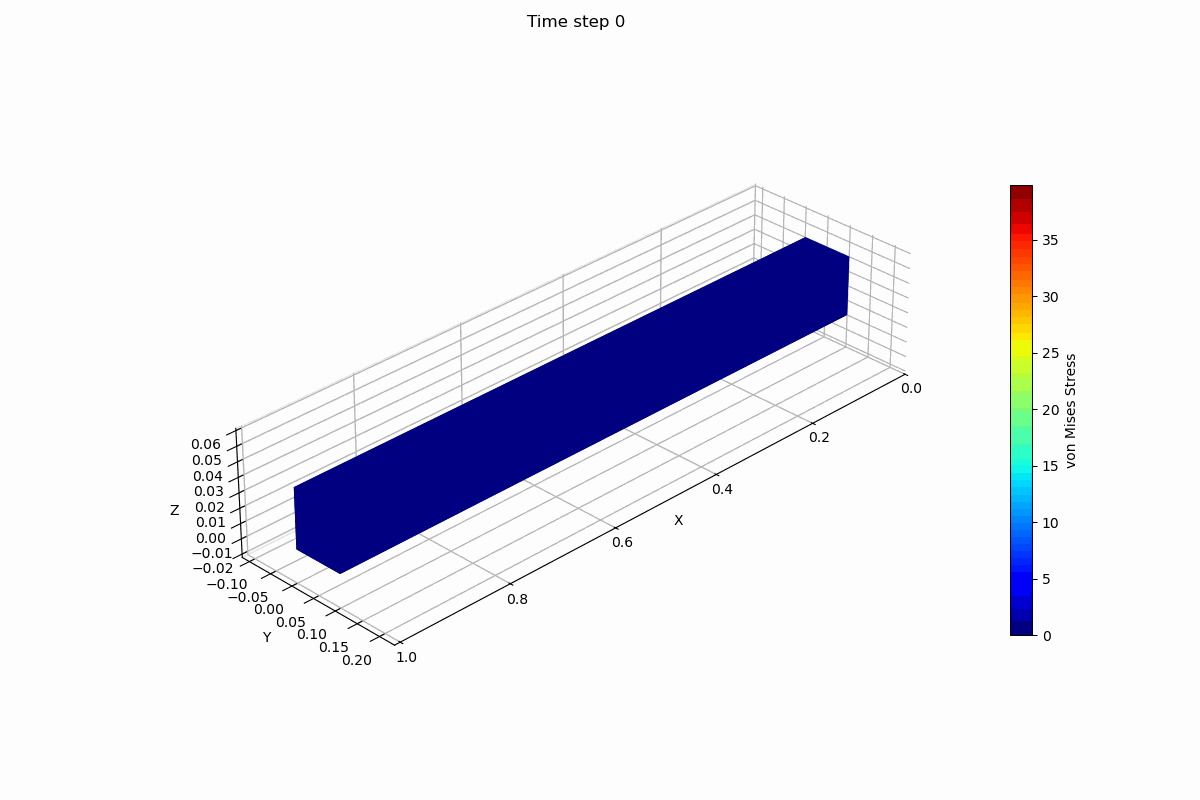

In [82]:
from IPython.display import Image, display

# After you've created "my_beam.gif", just do:
display(Image(filename="my_beam.gif"))
